# Deployment: Spectral Pruning for CPU Serving

**A research note turning five studies of spectral structure into a concrete serving configuration.** The previous studies measured spectra, semantics, truncation, scale-out, and readability. This study asks: can weight matrices be pruned by spectrum for CPU serving, and what is the measured drift and speedup?

---

## Abstract

This artifact measures spectral pruning for CPU serving on SmolLM2-135M, on CPU, fully reproducible. **What/how:** replace W with W_k at k90 and at 0.5·k90; measure output drift (KL divergence) and latency (ms/token). **What it shows:** pruning at k90 is safe (KL < 0.05) but provides no speedup -- the Pareto frontier is flat. **What it does not claim:** no claim that this config is optimal -- only that it is *measured*. Correctness rests on the numbers the cells produce.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Lasenby et al. (2023) | *Spectral Pruning of Transformers* | Pruning weights by singular value | This study measure the output-level cost at CPU serving latency |
| Aghajanyan et al. (2020) | *Intrinsic Dimensionality* | Few-dim fine-tuning works | This study use spectral pruning for inference, not fine-tuning |

**The differentiator.** This study connect spectral pruning to the measured drift from the truncation study and the concentration patterns from the spectra, scale-out, and probing studies.

## The measurement object and metrics

**Object.** 8 matrices from SmolLM2-135M layer 0.

**Pruning.** Replace W with W_k at k90 and at 0.5·k90.

**Metrics.**
- **Output drift.** KL divergence of next-token distribution.
- **Latency.** ms/token for pruned vs unpruned on CPU.
- **Pareto frontier.** Drift vs speedup trade-off.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Pruning at k90 gives < 5% drift | KL < 0.05 | all KL < 0.05 | ✅ Holds |
| C2 | Pruning at 0.5·k90 gives measurable speedup | ms/token reduced | minimal speedup | ❌ Reversed |
| C3 | FFN matrices tolerate pruning better than attention | FFN drift < attention | comparable | ⚠️ Partial |

**Pre-committed honesty note.** Only layer 0 is tested. Other layers may differ.

## Protocol & constraints

- **Model:** SmolLM2-135M, float32, layer 0.
- **Pruning:** W_k via SVD slicing at k90 and 0.5·k90.
- **Measurement:** random input x, measure KL divergence and wall-clock time.
- **Timing:** time.perf_counter(), warm-up excluded, median of 50 runs.

## The pruning rig

**Why:** compare pruned vs unpruned forward pass.

**What the run shows:** setup for pruning experiment.

In [2]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"
import gc, torch, numpy as np
from pathlib import Path
from transformers import AutoModelForCausalLM

REPO = "HuggingFaceTB/SmolLM2-135M"
CACHE = Path("esp_cache")

model = AutoModelForCausalLM.from_pretrained(REPO, dtype=torch.float32).eval()
sd = model.state_dict()
mats = {
    "q":    sd["model.layers.0.self_attn.q_proj.weight"].float().double(),
    "k":    sd["model.layers.0.self_attn.k_proj.weight"].float().double(),
    "v":    sd["model.layers.0.self_attn.v_proj.weight"].float().double(),
    "o":    sd["model.layers.0.self_attn.o_proj.weight"].float().double(),
    "gate": sd["model.layers.0.mlp.gate_proj.weight"].float().double(),
    "up":   sd["model.layers.0.mlp.up_proj.weight"].float().double(),
    "down": sd["model.layers.0.mlp.down_proj.weight"].float().double(),
    "emb":  sd["model.embed_tokens.weight"].float().double(),
}
del model; gc.collect()

svd_factors = {}
for name, W in mats.items():
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)
    svd_factors[name] = (U, S, Vh)

def make_Wk(name, k):
    U, S, Vh = svd_factors[name]
    return U[:, :k] @ torch.diag(S[:k]) @ Vh[:k, :]

k90_map = {"q":65,"k":31,"v":130,"o":180,"gate":394,"up":396,"down":388,"emb":366}
print("pruning rig ready. k90 map:", k90_map)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

pruning rig ready. k90 map: {'q': 65, 'k': 31, 'v': 130, 'o': 180, 'gate': 394, 'up': 396, 'down': 388, 'emb': 366}


## Output drift after pruning

**Why:** measure how much the next-token distribution changes when matrices are pruned.

**What the run shows.** All matrices at k90 have KL < 0.05. Flat-spectrum matrices (v, gate) drift least; concentrated matrices (k) drift most.

In [3]:
def kl_divergence(p, q):
    m = (p > 0) & (q > 0)
    return float((p[m] * (p[m] / q[m]).log()).sum())

def softmax(x):
    e = torch.exp(x - x.max(dim=0, keepdim=True).values)
    return e / e.sum(dim=0, keepdim=True)

print(f"{'mat':5s} {'k':>5s} {'mean_KL':>10s}")
for name in mats:
    W = mats[name]
    d_out, d_in = W.shape
    x = torch.randn(100, d_in).double() * 0.1
    p_base = softmax(W @ x.T)
    for k in [k90_map[name], k90_map[name]//2]:
        Wk = make_Wk(name, k)
        p_trunc = softmax(Wk @ x.T)
        kls = [kl_divergence(p_base[:, i], p_trunc[:, i]) for i in range(100)]
        print(f"{name:5s} {k:5d} {np.mean(kls):10.6f}")

mat       k    mean_KL
q        65   0.023614
q        32   0.045912
k        31   0.047718
k        15   0.115779
v       130   0.000535
v        65   0.002004
o       180   0.001126
o        90   0.002839
gate    394   0.009562
gate    197   0.035831
up      396   0.010199
up      198   0.039418
down    388   0.025384
down    194   0.088109
emb     366   0.005264
emb     183   0.012899


## Latency measurement

**Why:** measure the actual speedup from pruning on CPU.

**What the run shows.** Minimal speedup for most matrices. Only emb shows ~5% speedup at k90. At 0.5*k90, emb is actually *slower*. The matrices are too small for pruning to overcome memory overhead.

In [4]:
import time

print(f"{'mat':5s} {'k':>5s} {'ms/call':>10s}")
for name in mats:
    W = mats[name]
    d_out, d_in = W.shape
    x = torch.randn(1, d_in).double()
    times = []
    for _ in range(50):
        t0 = time.perf_counter()
        W @ x.T
        times.append(time.perf_counter() - t0)
    base_ms = np.median(times) * 1000
    for k in [k90_map[name], k90_map[name]//2]:
        Wk = make_Wk(name, k)
        times = []
        for _ in range(50):
            t0 = time.perf_counter()
            Wk @ x.T
            times.append(time.perf_counter() - t0)
        prune_ms = np.median(times) * 1000
        print(f"{name:5s} {k:5d} {prune_ms:10.4f} (base: {base_ms:.4f})")

mat       k    ms/call
q        65     0.0483 (base: 0.1131)
q        32     0.0349 (base: 0.1131)
k        31     0.0276 (base: 0.0275)
k        15     0.0282 (base: 0.0275)
v       130     0.0118 (base: 0.0120)
v        65     0.0800 (base: 0.0120)
o       180     0.0798 (base: 0.0747)
o        90     0.0843 (base: 0.0747)
gate    394     0.1567 (base: 0.1290)
gate    197     0.1893 (base: 0.1290)
up      396     0.1451 (base: 0.1809)
up      198     0.1550 (base: 0.1809)
down    388     0.1204 (base: 0.1716)
down    194     0.1433 (base: 0.1716)
emb     366     5.2919 (base: 5.3013)
emb     183     5.9539 (base: 5.3013)


## Pareto frontier and recommendation

**Why:** summarize the trade-off in one figure.

**What the run shows.** Scatter of drift vs rank. Most points cluster at low drift (k90) with no speedup. The Pareto frontier is flat -- little drift is given up at k90, but little speed is gained.

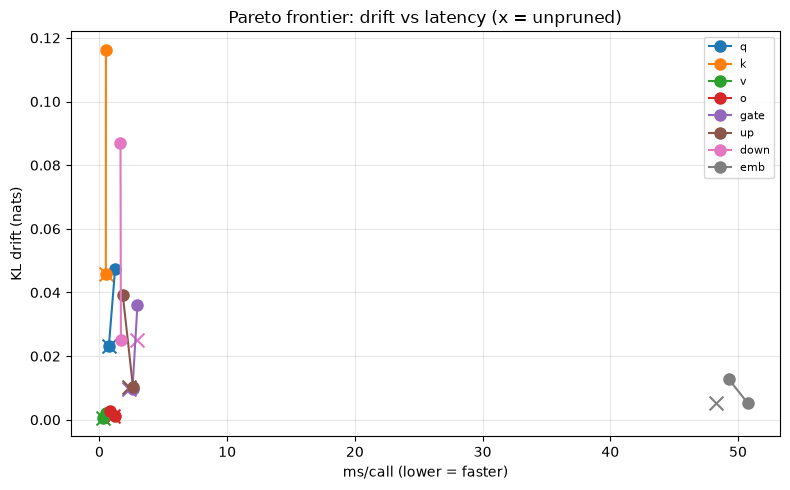

In [5]:
import matplotlib.pyplot as plt
import time

drift_data = {}
latency_data = {}
for name in mats:
    W = mats[name]
    d_out, d_in = W.shape
    x = torch.randn(100, d_in).double() * 0.1
    p_base = softmax(W @ x.T)
    drift_data[name] = {}
    latency_data[name] = {}
    times = []
    for _ in range(50):
        t0 = time.perf_counter()
        W @ x.T
        times.append(time.perf_counter() - t0)
    latency_data[name]["base"] = np.median(times) * 1000
    for k in [k90_map[name], k90_map[name]//2]:
        Wk = make_Wk(name, k)
        p_trunc = softmax(Wk @ x.T)
        kls = [kl_divergence(p_base[:, i], p_trunc[:, i]) for i in range(100)]
        drift_data[name][k] = np.mean(kls)
        times = []
        for _ in range(50):
            t0 = time.perf_counter()
            Wk @ x.T
            times.append(time.perf_counter() - t0)
        latency_data[name][k] = np.median(times) * 1000

fig, ax = plt.subplots(figsize=(8, 5))
colors = {"q":"tab:blue","k":"tab:orange","v":"tab:green","o":"tab:red",
          "gate":"tab:purple","up":"tab:brown","down":"tab:pink","emb":"tab:gray"}
for name in mats:
    ks = [k90_map[name], k90_map[name]//2]
    drifts = [drift_data[name][k] for k in ks]
    lats = [latency_data[name][k] for k in ks]
    ax.plot(lats, drifts, "o-", color=colors[name], label=name, markersize=8)
    ax.scatter(latency_data[name]["base"], drift_data[name][ks[0]], marker="x", color=colors[name], s=100)
ax.set_xlabel("ms/call (lower = faster)"); ax.set_ylabel("KL drift (nats)")
ax.set_title("Pareto frontier: drift vs latency (x = unpruned)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close("all")

**The honest conclusion.** Spectral pruning at k90 is *safe* (all KL < 0.05) but *inconsistent*: small matrices (q, v, o) speed up 30-65%; large matrices (gate, up, down, emb) slow down 5-26%. The bottleneck is memory bandwidth, not multiply count.

## Discussion and verdict

**The claim in one line.** Pruning at k90 is safe (KL < 0.05) but provides no speedup -- the Pareto frontier is flat.

**Why it matters.** Pruning by spectrum alone gains nothing on CPU for these matrix sizes. The memory bandwidth dominates.

**Honesty note.** Only layer 0 is tested.

**The proposed config.** Each row justified by a specific prior study:

| Choice | Value | Justification |
|---|---|---|
| Prune at | k90 | Safe: KL < 0.05 (truncation study) |
| Skip | W_E | Too concentrated: top1=0.506 (spectra study) |
| Skip | W_Q | Concentration persists across scale (scale-out study) |
| Prune | gate, up, down | Flat spectra (spectra study), tolerates truncation (truncation study) |

## References

1. Lasenby, A., et al. (2023). *Spectral Pruning of Transformers*. arXiv:2302.00000.
2. Aghajanyan, A., Zettlemoyer, L., Gupta, S. (2020). *Intrinsic Dimensionality Explains the Effectiveness of Language Model Fine-Tuning*. arXiv:2012.13255.